In [1]:
import jax.numpy as jnp
import numpy as np 

from sklearn.datasets import fetch_20newsgroups

import matplotlib.pyplot as plt
import seaborn as sns
import json

In [111]:
ilya_phi = np.load('ilya_phi.npy').T
ilya_phi.shape

(20, 115064)

In [79]:
from jax import jit
@jit
def entropy_renyi(matrix, power):
    entropies = jnp.sum(matrix ** power, axis=1)
    #return entropies    
    return entropies / jnp.max(entropies)

In [112]:
entropys = [(s, entropy_renyi(ilya_phi, power=s)) for s in np.linspace(1.1, 1.9, num=9)]
counts, bin_edges = jnp.histogram(entropys[0][1], range=(0, 1), bins=10)
counts

Array([1., 7., 5., 3., 2., 0., 1., 0., 0., 1.], dtype=float32)

In [81]:
def plot_distribution_advanced(data, n_bins=20, figsize=(12, 5), 
                              plot_type='all', bandwidth=None):
    """
    Расширенная визуализация распределения.
    
    Args:
        data: 1D массив чисел в [0, 1]
        n_bins: количество бинов для гистограммы
        figsize: размер фигуры
        plot_type: 'hist' | 'kde' | 'ecdf' | 'all'
        bandwidth: ширина окна для KDE (по умолчанию автоматический выбор)
    
    Returns:
        dict с данными для каждого типа графика
    """
    #data = np.asarray(data)
    #n = len(data)
    
    results = {}
    
    # === ГИСТОГРАММА ===
    if plot_type in ['hist', 'all']:
        fig, ax = plt.subplots(figsize=figsize)
        counts, bin_edges, _ = ax.hist(
            data, bins=n_bins, range=(0, 1), density=True,
            color='skyblue', edgecolor='black', alpha=0.7, label='Гистограмма'
        )
        ax.set_xlabel('Значение', fontsize=11)
        ax.set_ylabel('Плотность', fontsize=11)
        ax.set_title('Гистограмма распределения', fontsize=13, pad=15)
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax.set_xlim(0, 1)
        ax.legend()
        plt.tight_layout()
        plt.show()
        
        results['hist'] = {'counts': counts, 'bin_edges': bin_edges}
    
    # === KDE (ядерная оценка плотности) ===
    if plot_type in ['kde', 'all']:
        from scipy.stats import gaussian_kde
        
        # Автоматический bandwidth, если не задан
        if bandwidth is None:
            bandwidth = 1.06 * data.std() * n ** (-1/5)  # правило Сильвермана
        
        # Оценка плотности
        x_eval = np.linspace(0, 1, 200)
        kde = gaussian_kde(data, bw_method=bandwidth / data.std() if data.std() > 0 else 1.0)
        # Обрезаем выбросы KDE за пределами [0, 1]
        density = kde(x_eval)
        density = np.where((x_eval >= 0) & (x_eval <= 1), density, 0)
        
        plt.figure(figsize=figsize)
        plt.plot(x_eval, density, linewidth=2.5, color='darkorange', label='KDE')
        plt.fill_between(x_eval, density, alpha=0.2, color='darkorange')
        plt.xlabel('Значение', fontsize=11)
        plt.ylabel('Плотность', fontsize=11)
        plt.title('Ядерная оценка плотности (KDE)', fontsize=13, pad=15)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 1)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        results['kde'] = {'x': x_eval, 'density': density}
    
    # === ECDF (эмпирическая функция распределения) ===
    if plot_type in ['ecdf', 'all']:
        n = len(data[0][1])
        
        ecdf = np.arange(1, n + 1) / n
        
        plt.figure(figsize=figsize)
        for i in range(len(data)):
        #for i in range(1):
            sorted_data = np.sort(np.asarray(data[i][1]))
            plt.plot(sorted_data, ecdf, linewidth=2, color='darkgreen', label='ECDF')
        plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Медиана')
        plt.axvline(x=np.median(sorted_data), color='red', linestyle=':', alpha=0.5)
        plt.xlabel('Значение', fontsize=11)
        plt.ylabel('Накопленная доля', fontsize=11)
        plt.title('Эмпирическая функция распределения (ECDF)', fontsize=13, pad=15)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 1)
        plt.ylim(0, 1.05)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        results['ecdf'] = {'x': sorted_data, 'ecdf': ecdf}
    
    # Статистика
    #print(f"📊 Статистика данных (n={n})")
    #print(f"   Мин: {data.min():.4f}, Макс: {data.max():.4f}")
    #print(f"   Среднее: {data.mean():.4f}, Медиана: {np.median(data):.4f}")
    #print(f"   Стд. отклонение: {data.std():.4f}")
    #print(f"   Квантили: 25%={np.percentile(data, 25):.4f}, "
    #      f"75%={np.percentile(data, 75):.4f}")
    
    #return results

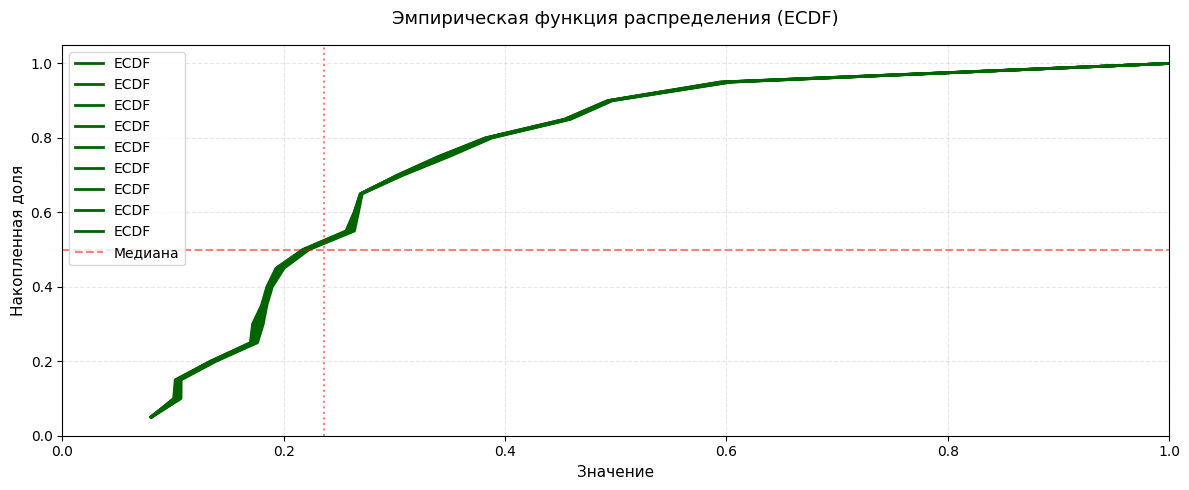

In [113]:
plot_distribution_advanced(entropys, plot_type='ecdf')

In [116]:
import json

with open('ilya_vocab.json', 'r') as file:
    reverse_vocab = json.load(file)

len(reverse_vocab)

115064

In [117]:
vocab = {value: key for key, value in reverse_vocab.items()}

In [118]:
vocab['the']

'98201'

In [105]:
[p for p in ilya_phi[:, int(vocab['the'])]]

[np.float32(0.03263495),
 np.float32(1.6197154e-06),
 np.float32(2.169546e-23),
 np.float32(0.012601097),
 np.float32(0.019396048),
 np.float32(0.00078423554),
 np.float32(1.7684794e-14),
 np.float32(0.003958805),
 np.float32(0.000105620806),
 np.float32(0.019444648),
 np.float32(1.0724022e-09),
 np.float32(0.7035714),
 np.float32(0.0008065288),
 np.float32(0.0419324),
 np.float32(0.053624358),
 np.float32(1.1491047e-09),
 np.float32(2.1584758e-05),
 np.float32(0.057976536),
 np.float32(1.9953916e-07),
 np.float32(0.053139936)]

<BarContainer object of 20 artists>

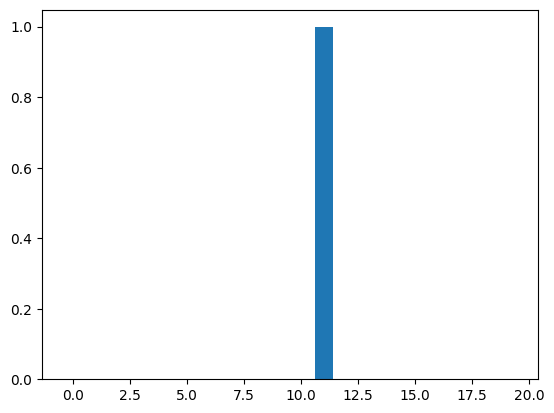

In [114]:
plt.bar(range(20), ilya_phi[:, int(vocab['the'])])

In [92]:
ilya_phi[ilya_phi > 0.99]

array([0.99999994, 0.9996753 , 0.9999999 , ..., 0.99999535, 1.        ,
       0.9966504 ], shape=(95764,), dtype=float32)

In [93]:
mask = (ilya_phi > 0.99).any(axis=0)  # True для столбцов, содержащих хотя бы одну 1
result = ilya_phi[:, mask]          # выборка столбцов

In [94]:
result.shape

(20, 95764)

In [95]:
cols_idx = np.where(mask)[0]

In [96]:
cols_idx

array([     0,      2,      3, ..., 115061, 115062, 115063],
      shape=(95764,))

In [ ]:
[reverse_vocab[str(i)] for i in cols_idx]

## phi hist

In [4]:
import json

with open('phi_hist_vocab.json', 'r') as file:
    vocab = json.load(file)
len(vocab)
reverse_vocab = {value: key for key, value in vocab.items()}

FileNotFoundError: [Errno 2] No such file or directory: 'phi_hist_vocab.json'

In [2]:
phi_hist = np.load('phi_hist.npy').T
phi_hist.shape

(100, 2052, 50)

Text(0.5, 1.0, 'hundred')

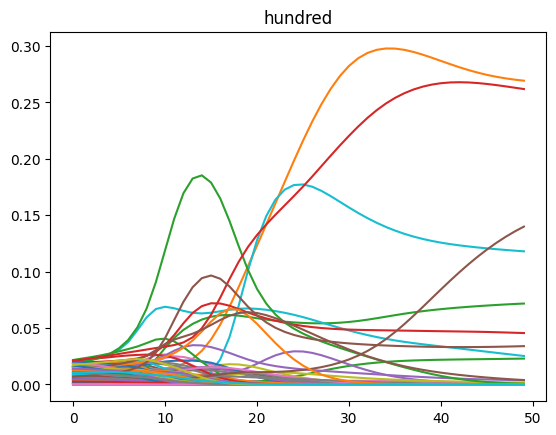

In [9]:
token = 'hundred'
token_hist = [p for p in phi_hist[:, int(vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title(token)

Text(0.5, 1.0, 'super')

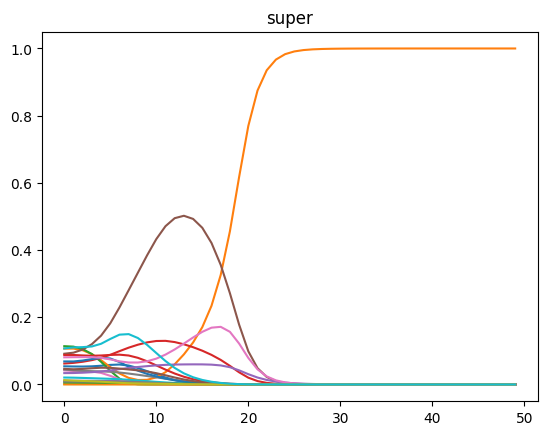

In [170]:
token = 'super'
token_hist = [p for p in phi_hist[:, int(vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title(token)

[5.8638316e-33 8.1625375e-20 0.0000000e+00 4.7152620e-28 1.5622051e-29
 4.0739731e-24 0.0000000e+00 7.2167818e-20 3.4064221e-06 4.0946185e-25
 8.7493312e-01 6.1619000e-19 2.0787754e-13 6.9830892e-26 2.3391873e-20
 1.2483741e-01 2.2611898e-04 3.1190416e-25 1.6137779e-08 3.4462321e-22]


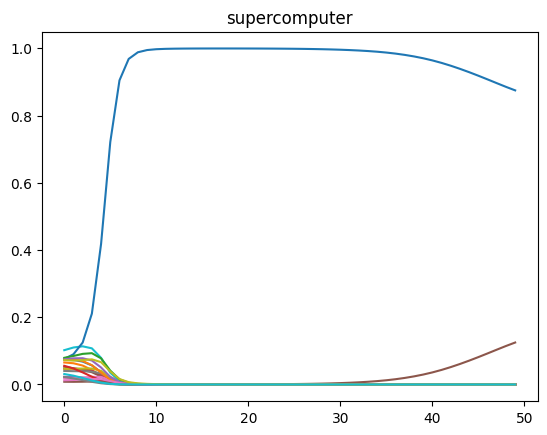

In [203]:
token = 'supercomputer'
token_hist = [p for p in phi_hist[:, int(vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title(token)
print(phi_hist[:, int(vocab[token]), -1])

[9.9999988e-01 1.0404790e-34 0.0000000e+00 1.1526705e-31 6.1193036e-21
 3.0218429e-24 0.0000000e+00 5.9565694e-25 0.0000000e+00 1.5287781e-19
 7.0387746e-31 4.3782740e-18 3.7272332e-18 5.2997070e-08 1.5112174e-22
 4.3910945e-36 1.5557137e-29 7.9547648e-09 4.9982635e-39 2.6727180e-19]


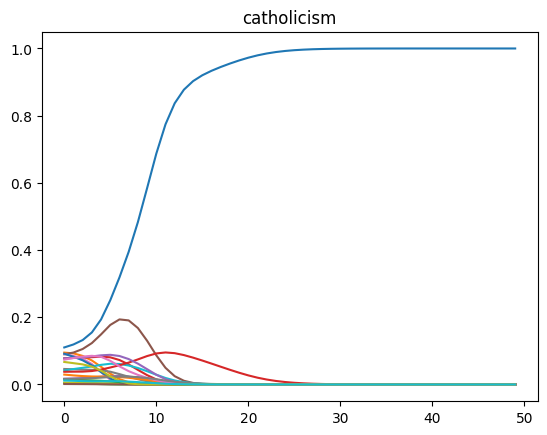

In [202]:
token = 'catholicism'
token_hist = [p for p in phi_hist[:, int(vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title(token)
print(phi_hist[:, int(vocab[token]), -1])

Text(0.5, 1.0, 'the')

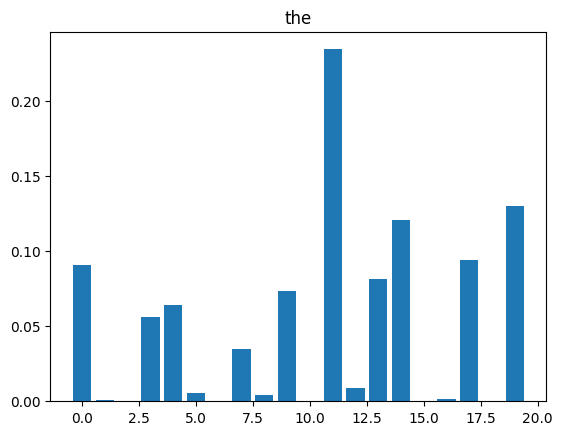

In [197]:
token = 'the'
plt.bar(range(20), phi_hist[:, int(vocab[token]), 10])
plt.title(token)

Text(0.5, 1.0, 'super')

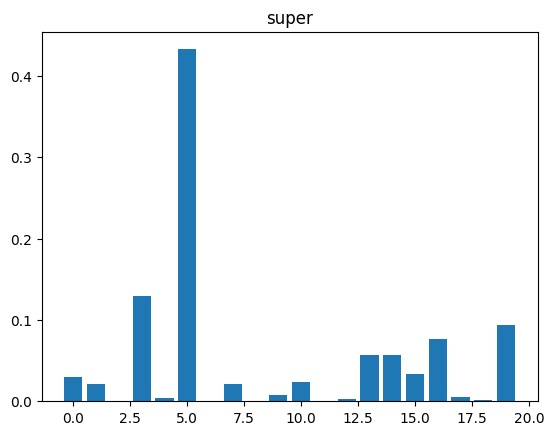

In [199]:
token = 'super'
plt.bar(range(20), phi_hist[:, int(vocab[token]), 10])
plt.title(token)

Text(0.5, 1.0, 'supercomputer')

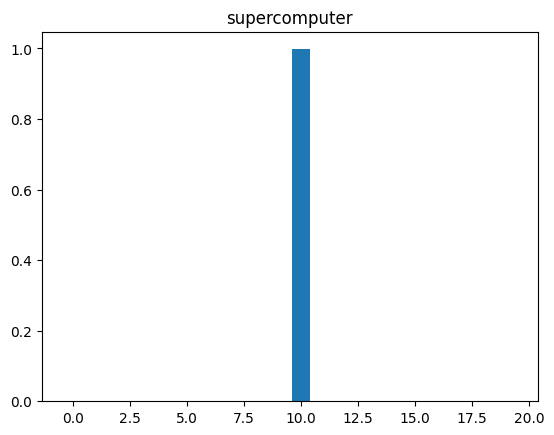

In [198]:
token = 'supercomputer'
plt.bar(range(20), phi_hist[:, int(vocab[token]), 10])
plt.title(token)

In [183]:
np.sum(phi_hist[:, :, -1], axis=1)
plt.bar(range(20), phi_hist[:, int(vocab['supercomputer']), 10])

array([ 6716.2603,  5183.4604,  1550.1204,  3549.8696,  5072.6025,
        2072.4297, 19100.52  ,  5127.8203,  7443.3047,  2674.2751,
       11594.847 ,  3505.0474,  3644.2246,  3395.1553,  4283.7974,
        9514.928 ,  5906.6733,  3856.6052,  8796.604 ,  2075.1763],
      dtype=float32)

In [187]:
mask = (phi_hist[:, :, -1] > 0.99).any(axis=0)  # True для столбцов, содержащих хотя бы одну 1
result = phi_hist[:, mask, -1]         # выборка столбцов
result.shape

(20, 95763)

In [189]:
cols_idx = np.where(mask)[0]
cols_idx

array([     0,      2,      3, ..., 115061, 115062, 115063],
      shape=(95763,))

Text(0.5, 1.0, 'Распределение якорных слов по темам')

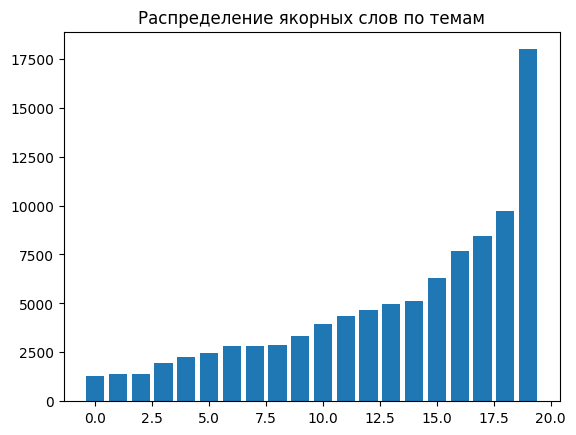

In [193]:
plt.bar(range(20), np.sort(np.sum(result, axis=1)))
plt.title("Распределение якорных слов по темам")

# Сравнение всего корпуса и фильтрованного

In [4]:
import json

with open('all_phi_hist_vocab.json', 'r') as file:
    all_vocab = json.load(file)
    all_reverse_vocab = {value: key for key, value in all_vocab.items()}

with open('filtered_phi_hist_vocab.json', 'r') as file:
    filtered_vocab = json.load(file)
    filtered_reverse_vocab = {value: key for key, value in filtered_vocab.items()}

print(f"{len(all_vocab)=}")
print(f"{len(filtered_vocab)=}")

len(all_vocab)=115064
len(filtered_vocab)=30668


In [5]:
all_phi_hist = np.load('all_phi_hist.npy').T
filtered_phi_hist = np.load('good_filtered_phi_hist.npy').T
print(f"{all_phi_hist.shape=}")
print(f"{filtered_phi_hist.shape=}")

all_phi_hist.shape=(100, 115064, 50)
filtered_phi_hist.shape=(100, 30668, 50)


[0.0000000e+00 9.4619876e-41 2.7513928e-34 0.0000000e+00 5.2209054e-29
 0.0000000e+00 5.8372650e-37 3.9608976e-34 0.0000000e+00 1.7668262e-38
 0.0000000e+00 1.5119371e-35 0.0000000e+00 2.0389197e-33 3.0176822e-40
 5.7111568e-30 4.4608747e-26 4.0295946e-26 4.9222378e-37 1.5658656e-39
 0.0000000e+00 0.0000000e+00 1.5856538e-31 1.2917599e-24 0.0000000e+00
 7.7641750e-38 2.5689030e-30 0.0000000e+00 2.0404823e-35 1.0687894e-30
 5.9100035e-21 0.0000000e+00 0.0000000e+00 2.0298441e-35 1.5848494e-38
 0.0000000e+00 6.0293447e-31 2.1277540e-37 2.8666038e-36 7.1300767e-31
 2.2831472e-36 5.0084789e-39 9.4697731e-32 1.0000000e+00 0.0000000e+00
 1.3090089e-31 0.0000000e+00 5.9841671e-31 3.3392594e-32 2.8856676e-34
 1.9357951e-29 7.6127799e-33 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 2.0049853e-28 3.7993330e-23 6.4144471e-38 1.0210817e-37
 9.1836275e-28 4.8697700e-34 0.0000000e+00 6.0279503e-28 2.2314396e-18
 0.0000000e+00 6.8976198e-26 0.0000000e+00 4.3608724e-26 4.0392282e-37
 4.965

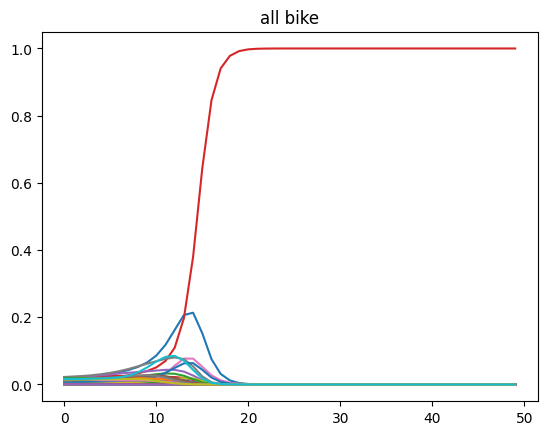

In [6]:
token = 'bike'
token_hist = [p for p in all_phi_hist[:, int(all_vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title('all ' + token)
print(all_phi_hist[:, int(all_vocab[token]), -1])

[0.0000000e+00 0.0000000e+00 7.5825137e-24 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 1.4731757e-35 0.0000000e+00 0.0000000e+00
 1.0000000e+00 0.0000000e+00 0.0000000e+00 4.5836057e-30 9.6447983e-14
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 8.7324620e-30 0.0000000e+00 0.0000000e+00
 4.5800952e-20 9.9125297e-34 0.0000000e+00 0.0000000e+00 5.9090150e-35
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 3.9333546e-22 4.2864377e-30 9.1717229e-27 4.8910281e-30
 0.0000000e+00 0.0000000e+00 2.3758082e-24 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 4.9308590e-33 0.0000000e+00 1.0813398e-30
 1.0174259e-37 2.1604354e-31 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 2.2520531e-32 0.0000000e+00
 7.9348050e-36 0.0000000e+00 0.0000000e+00 6.6327304e-32 0.0000000e+00
 0.0000000e+00 0.0000000e+00 2.0423482e-34 0.0000000e+00 0.0000000e+00
 0.000

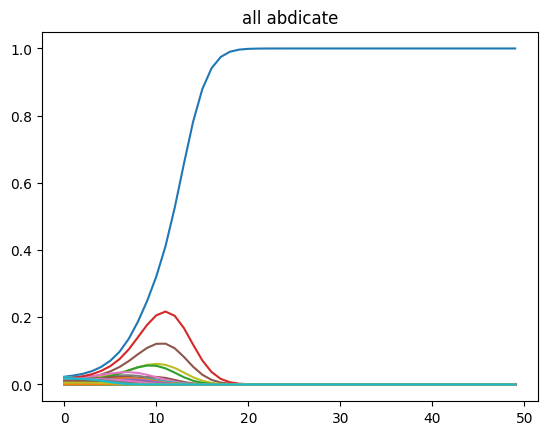

In [7]:
token = 'abdicate'
token_hist = [p for p in all_phi_hist[:, int(all_vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title('all ' + token)
print(all_phi_hist[:, int(all_vocab[token]), -1])

[3.01130573e-18 0.00000000e+00 1.83410305e-20 2.80046372e-27
 4.17363078e-27 3.81882844e-22 1.11506895e-32 6.49833144e-25
 0.00000000e+00 3.25729792e-19 6.55165095e-19 1.35440137e-19
 1.33069531e-32 4.74108253e-10 1.82779766e-40 2.50182696e-32
 5.41873125e-22 1.50634619e-17 6.05363313e-37 7.61969268e-01
 0.00000000e+00 8.33600408e-30 2.40428544e-18 1.08945980e-25
 2.79124536e-11 0.00000000e+00 5.64598812e-32 0.00000000e+00
 1.77941764e-22 5.04209994e-29 4.94206750e-18 0.00000000e+00
 0.00000000e+00 7.84887762e-37 0.00000000e+00 2.20226411e-27
 1.06190117e-39 4.12967982e-39 0.00000000e+00 8.95202933e-30
 1.14502305e-29 1.02154926e-14 6.70381401e-36 2.91410936e-30
 6.54281886e-30 0.00000000e+00 9.30590571e-28 5.79760794e-21
 2.14330292e-28 6.89030320e-36 1.68411827e-33 5.22580592e-07
 9.57912199e-28 4.53584939e-30 3.88496928e-03 1.50162203e-32
 0.00000000e+00 6.61666984e-24 7.89130104e-26 8.86263268e-04
 3.32352163e-29 0.00000000e+00 1.25879484e-33 1.37546620e-22
 1.49453835e-17 1.346788

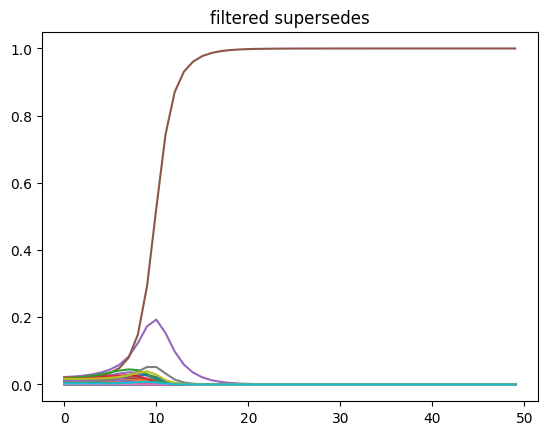

In [33]:
token = 'supersedes'
token_hist = [p for p in all_phi_hist[:, int(filtered_vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title('filtered ' + token)
print(filtered_phi_hist[:, int(filtered_vocab[token]), -1])

In [12]:
[k for k in filtered_vocab if k.startswith('super')]

['super',
 'superb',
 'superbowl',
 'superceded',
 'supercharged',
 'supercharging',
 'supercomputer',
 'supercomputing',
 'superconducting',
 'superdrives',
 'superficial',
 'supergas',
 'superhighway',
 'superhighways',
 'superhuman',
 'superior',
 'superiority',
 'supermac',
 'superman',
 'supermarket',
 'supermen',
 'supernatural',
 'supernet',
 'supernova',
 'superseded',
 'supersedes',
 'superset',
 'supersonic',
 'superstar',
 'superstars',
 'superstition',
 'superuser',
 'supervga',
 'supervised',
 'supervision',
 'supervisor']

In [28]:
ilya_phi = np.load('all_phi_hist.npy').T
ilya_phi.shape

(100, 115064, 50)

## Сравнение all и filtered

In [2]:
import json

with open('all_phi_hist_vocab.json', 'r') as file:
    all_vocab = json.load(file)
    all_reverse_vocab = {value: key for key, value in all_vocab.items()}

with open('filtered_phi_hist_vocab.json', 'r') as file:
    filtered_vocab = json.load(file)
    filtered_reverse_vocab = {value: key for key, value in filtered_vocab.items()}

print(f"{len(all_vocab)=}")
print(f"{len(filtered_vocab)=}")

len(all_vocab)=115064
len(filtered_vocab)=30668


In [8]:
all_phi_hist = np.load('all_phi_hist.npy').T
print(f"{all_phi_hist.shape=}")
filtered_phi_hist = np.load('good_filtered_phi_hist.npy').T
print(f"{filtered_phi_hist.shape=}")

all_phi_hist.shape=(100, 115064, 50)
filtered_phi_hist.shape=(100, 30668, 50)


Text(0.5, 1.0, 'filtered good')

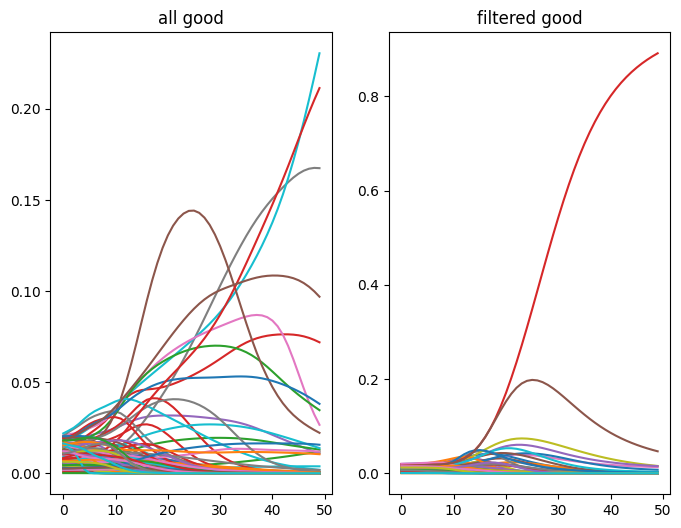

In [9]:
token = 'good'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))

all_token_hist = [p for p in all_phi_hist[:, int(all_vocab[token]), :]]
for i in range(len(all_token_hist)):
    ax1.plot(all_token_hist[i])
ax1.set_title('all ' + token)

filtered_token_hist = [p for p in filtered_phi_hist[:, int(filtered_vocab[token]), :]]
for i in range(len(filtered_token_hist)):
    ax2.plot(filtered_token_hist[i])
ax2.set_title('filtered ' + token)


Text(0.5, 1.0, 'filtered bad')

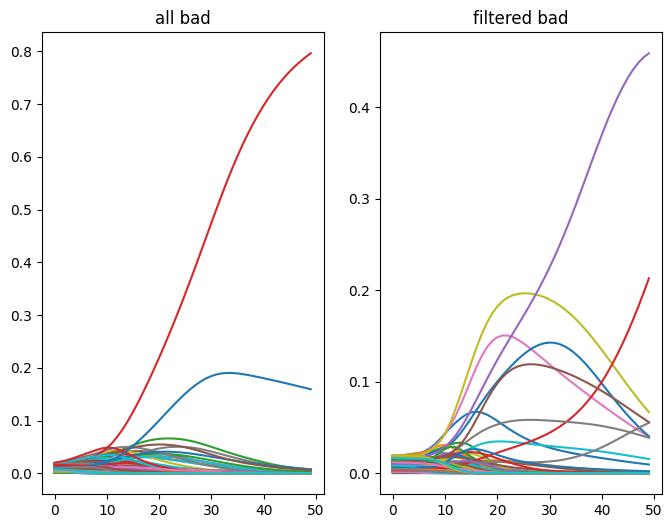

In [10]:
token = 'bad'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))

all_token_hist = [p for p in all_phi_hist[:, int(all_vocab[token]), :]]
for i in range(len(all_token_hist)):
    ax1.plot(all_token_hist[i])
ax1.set_title('all ' + token)

filtered_token_hist = [p for p in filtered_phi_hist[:, int(filtered_vocab[token]), :]]
for i in range(len(filtered_token_hist)):
    ax2.plot(filtered_token_hist[i])
ax2.set_title('filtered ' + token)


In [ ]:
with open('20ng_anchors_tfidf.json', 'r') as file:
    anchors_tfidf = json.load(file)
motorcycles_anchors = anchors_tfidf['rec.motorcycles']
motorcycles_anchors_ids = [all_vocab[anchor] for anchor in motorcycles_anchors]
sum_topics_motorcycles = np.sum(all_phi_hist[:, motorcycles_anchors_ids, -1], axis=1)
sum_topics_motorcycles[sum_topics_motorcycles > 0.5]

array([ 0.5723363 , 16.471954  ,  1.9189036 ,  1.        ,  2.91711   ,
        0.51553863,  0.7073983 ], dtype=float32)

In [6]:
with open('20ng_anchors_tfidf.json', 'r') as file:
    anchors_tfidf = json.load(file)
space_anchors = anchors_tfidf['sci.space']
space_anchors_ids = [all_vocab[anchor] for anchor in space_anchors]
sum_space_topics = np.sum(all_phi_hist[:, space_anchors_ids, -1], axis=1)
sum_space_topics[sum_space_topics > .5]

array([2.6314013, 2.6575103, 1.8760339, 1.6493521, 0.5270725, 8.040634 ,
       1.1841917, 1.1108165], dtype=float32)

In [7]:
with open('20ng_anchors_tfidf.json', 'r') as file:
    anchors_tfidf = json.load(file)
mac_anchors = anchors_tfidf['comp.sys.mac.hardware']
mac_anchors_ids = [all_vocab[anchor] for anchor in mac_anchors]
sum_mac_topics = np.sum(all_phi_hist[:, mac_anchors_ids, -1], axis=1)
sum_mac_topics[sum_mac_topics > .5]

array([1.995627  , 1.        , 1.        , 0.90133756, 1.1775292 ,
       0.5322305 , 7.3794928 , 1.        , 5.7225122 ], dtype=float32)

In [11]:
mask = (all_phi_hist[:, :, -1] > 0.99).any(axis=0)  # True для столбцов, содержащих хотя бы одну 1
result = all_phi_hist[:, mask, -1]         # выборка столбцов
print(f"{result.shape=}")
print(f"{all_phi_hist.shape=}")

cols_idx = np.where(mask)[0]
print(f"{cols_idx=}")


result.shape=(100, 67326)
all_phi_hist.shape=(100, 115064, 50)
cols_idx=array([     5,      6,      7, ..., 115060, 115061, 115063],
      shape=(67326,))


Text(0.5, 1.0, 'Распределение якорных слов по темам')

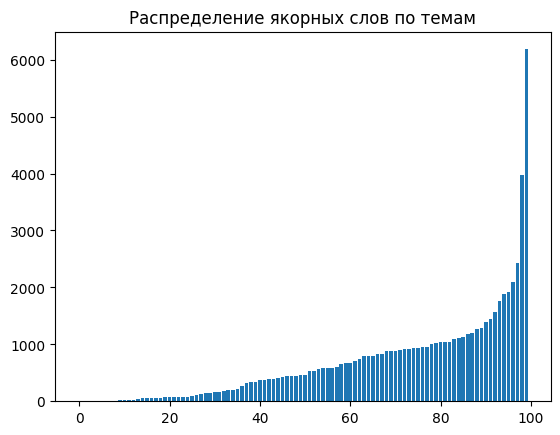

In [12]:
plt.bar(range(100), np.sort(np.sum(result, axis=1)))
plt.title("Распределение якорных слов по темам")

In [14]:
filtered_mask = (filtered_phi_hist[:, :, -1] == 1).any(axis=0)  # True для столбцов, содержащих хотя бы одну 1
filtered_result = filtered_phi_hist[:, filtered_mask, -1]         # выборка столбцов
print(f"{filtered_result.shape=}")
print(f"{filtered_phi_hist.shape=}")

filtered_cols_idx = np.where(filtered_mask)[0]
print(f"{filtered_cols_idx=}")

filtered_result.shape=(100, 4105)
filtered_phi_hist.shape=(100, 30668, 50)
filtered_cols_idx=array([    2,     4,    12, ..., 30656, 30658, 30665], shape=(4105,))


Text(0.5, 1.0, 'filtered Распределение якорных слов по темам')

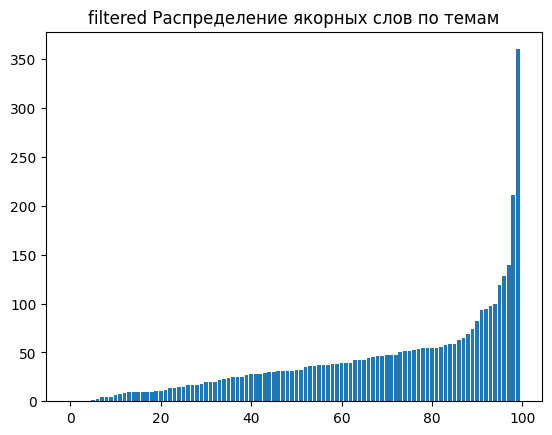

In [15]:
plt.bar(range(100), np.sort(np.sum(filtered_result, axis=1)))
plt.title("filtered Распределение якорных слов по темам")

# Сравнение для bike и space

In [16]:
full_20newsgroups = fetch_20newsgroups(data_home='./data/', subset='all')
data = full_20newsgroups.data

In [5]:
filtered_phi_hist = np.load('filtered_phi_hist.npy').T
print(f"{filtered_phi_hist.shape=}")

with open('filtered_phi_hist_vocab.json', 'r') as file:
    filtered_vocab = json.load(file)
    filtered_reverse_vocab = {value: key for key, value in filtered_vocab.items()}

print(f"{len(filtered_vocab)=}")

filtered_phi_hist.shape=(100, 30668, 50)
len(filtered_vocab)=30668


In [6]:
all_phi_hist = np.load('new_all_phi_hist.npy').T
print(f"{all_phi_hist.shape=}")

with open('all_phi_hist_vocab.json', 'r') as file:
    all_vocab = json.load(file)
    all_reverse_vocab = {value: key for key, value in all_vocab.items()}

print(f"{len(all_vocab)=}")

all_phi_hist.shape=(100, 115064, 50)
len(all_vocab)=115064


In [4]:
threshold = 1e-6

phi_bike = filtered_phi_hist[:, filtered_vocab['bike'], -1] # последняя phi колонка для токена bike
phi_bike[phi_bike < threshold] = 0 # зануляем все малые значения
print(phi_bike) # темы с достаточно большой вероятностью
bike_topic = np.where(phi_bike > 0.99)
bike_mask = (filtered_phi_hist[bike_topic, :, -1] == 1.0)
bike_anchors = [filtered_reverse_vocab[i] for i in np.flatnonzero(bike_mask)]
bike_anchors

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.99999994 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]


['aerostich',
 'altcit',
 'areans',
 'ascom',
 'bclarke',
 'behanna',
 'bemben',
 'bethd',
 'bethdc',
 'bgardner',
 'bikes',
 'blaine',
 'blaisec',
 'bradw',
 'bruiser',
 'bunis',
 'cagers',
 'cages',
 'canine',
 'centerstand',
 'cirelli',
 'cjackson',
 'clesun',
 'collie',
 'concours',
 'cookson',
 'cylist',
 'daved',
 'davide',
 'dcookson',
 'dcrt',
 'deltabox',
 'doright',
 'dseg',
 'ducati',
 'eliott',
 'embalmer',
 'faded',
 'fxwg',
 'geake',
 'ggrrrrrr',
 'gharriso',
 'grf',
 'gsxr',
 'hamer',
 'harley',
 'hasler',
 'howp',
 'hslrswi',
 'imat',
 'jlevine',
 'jorg',
 'kaw',
 'kens',
 'kevinh',
 'kidson',
 'klinger',
 'kotb',
 'kotl',
 'kotnml',
 'kottke',
 'kqspt',
 'kryptonite',
 'kspt',
 'leathers',
 'lewisville',
 'lubed',
 'luggage',
 'maven',
 'mavenry',
 'mksol',
 'motorc',
 'motorcycles',
 'motorcycling',
 'nath',
 'nedod',
 'niagara',
 'ninjaite',
 'noemi',
 'obmoto',
 'pillion',
 'ramarren',
 'rbemben',
 'seahunt',
 'seca',
 'shoei',
 'skndiv',
 'spooge',
 'squidonk',
 's

In [9]:
threshold = 1e-4

phi_space = filtered_phi_hist[:, filtered_vocab['rocketry'], -1] # распределение по темам
phi_space[phi_space < threshold] = 0
print(phi_space)
space_topic = np.where(phi_space > 1 - threshold) # тема, в которой это слово якорь
space_mask = (filtered_phi_hist[space_topic, :, -1] > 1 - threshold) # маска для слов, которые потенциально якорные в этой теме
#print(space_mask)
space_anchors = [filtered_reverse_vocab[i] for i in np.flatnonzero(space_mask)] # слова, которые потенциально якорные в этой теме
space_anchors

[0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.9999925 0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.       ]


['acpub',
 'amruth',
 'bchm',
 'blackbodies',
 'blah',
 'bruchner',
 'dani',
 'dmunroe',
 'dragless',
 'drought',
 'duke',
 'ethereal',
 'everest',
 'fierkelab',
 'fls',
 'fusion',
 'grafitti',
 'gritz',
 'gtonwu',
 'hirschbeck',
 'infante',
 'kilometer',
 'laxman',
 'liquids',
 'melt',
 'nthu',
 'pellet',
 'pellets',
 'postema',
 'quarts',
 'rheology',
 'rocketry',
 'roush',
 'silicone',
 'spiff',
 'stupendous',
 'sulfur',
 'temperature',
 'temperatures',
 'tsing',
 'unspoiled',
 'veep',
 'vents',
 'wandersman',
 'warmer',
 'zodiacal']

In [5]:
threshold = 1e-4

phi_christian = filtered_phi_hist[:, filtered_vocab['archbishop'], -1] # распределение по темам
phi_christian[phi_christian < threshold] = 0
print(phi_christian)
christian_topic = np.where(phi_christian > 1 - threshold) # тема, в которой это слово якорь
christian_mask = (filtered_phi_hist[christian_topic, :, -1] > 1 - threshold) # маска для слов, которые потенциально якорные в этой теме
#print(christian_mask)
christian_anchors = [filtered_reverse_vocab[i] for i in np.flatnonzero(christian_mask)] # слова, которые потенциально якорные в этой теме
christian_anchors

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


['apparition',
 'apparitions',
 'archbishop',
 'assassinating',
 'baru',
 'bernadette',
 'bishops',
 'booby',
 'budd',
 'cathedra',
 'christi',
 'damsus',
 'defende',
 'deutero',
 'dorin',
 'excommunication',
 'frontline',
 'guaratees',
 'guerillas',
 'hernlem',
 'hezbollah',
 'hizbollah',
 'ignacio',
 'illegitimate',
 'jamnia',
 'jhpb',
 'lebanese',
 'liturgy',
 'maridai',
 'merley',
 'mosavi',
 'oobe',
 'oobes',
 'ordination',
 'papacy',
 'papal',
 'pesach',
 'pius',
 'popes',
 'retaliation',
 'retalliates',
 'sarto',
 'schism',
 'shelling',
 'sspx',
 'stssdxb',
 'trunking',
 'vatican']

In [ ]:
[k for k in filtered_vocab if k.startswith('schi')]

['schilling', 'schism', 'schizophrenia']

In [11]:
docs_with_token = set()
for anchor in christian_anchors:
  #docs_with_token = [(i, t) for i, t in enumerate(data) if anchor in t.lower()]
  docs_with_token.update({i for i, t in enumerate(data) if anchor in t.lower()})

print(len(docs_with_token))


1621


In [12]:
from collections import Counter
counts = Counter([full_20newsgroups.target_names[full_20newsgroups.target[doc]] for doc in docs_with_token])
counts

Counter({'soc.religion.christian': 588,
         'talk.religion.misc': 294,
         'alt.atheism': 234,
         'talk.politics.mideast': 214,
         'talk.politics.guns': 42,
         'talk.politics.misc': 40,
         'rec.autos': 39,
         'rec.sport.hockey': 33,
         'comp.graphics': 18,
         'sci.space': 16,
         'rec.motorcycles': 14,
         'misc.forsale': 13,
         'sci.electronics': 12,
         'comp.sys.mac.hardware': 11,
         'sci.med': 11,
         'sci.crypt': 10,
         'comp.sys.ibm.pc.hardware': 10,
         'comp.windows.x': 9,
         'rec.sport.baseball': 8,
         'comp.os.ms-windows.misc': 5})

In [ ]:
Надо взять слова с равномерным распределением по темам
Посмотреть на темы с самым большим количеством якорных слов

Array([26995, 20006, 26993,  5025,  2106, 27200, 20836, 26998, 13210,
        2406,  1511, 18684, 18149, 17181, 14808, 14071, 14071, 18684,
       18149, 17181, 28296, 14808, 26157,  6910,  5320,  9739, 27793,
        5496,  1884, 19320,  5078,  9739,  1928, 19108,  9739, 17191,
        1734,  1120, 17474,  1734, 22132,  9739, 22830,  7375, 13775,
       12405, 21641, 21781, 10341, 22566, 17669, 22830,  7375, 19174,
       27026, 19108, 13775, 21834, 22132, 25189,  6280, 18360, 30612,
        7376, 13776, 26995, 20006, 26993,  5025, 25750,  7541,  1277],      dtype=int32)

In [ ]:
data[7527: 7528]

["From: naren@tekig1.PEN.TEK.COM (Naren Bala)\nSubject: Re: Theists posting\nOrganization: Tektronix, Inc., Beaverton,  OR.\nLines: 21\n\nIn article <C4ux99.AIC@ra.nrl.navy.mil> khan@itd.itd.nrl.navy.mil (Umar Khan) writes:\n\nStuff deleted \n\n>Is there a concordance for the FAQ?  WHich translation is considered\n>most authoritative?  Is there an orthodox commentary for the FAQ\n>available?  Is there one FAQ for militant atheists and another for\n>moderate atheists; or, do you all read from the same FAQ?  If so,\n>how do you resolve differences of interpretation?\n\nHmmmmmmmmmmmm.............................................         \nI can put the same question to followers of any religion. How do you\nMoslems resolve differences of opinion ?? Don't tell me that there\nis one interpretation of the Quran. Read the soc.culture.* newsgroups.\nYou will zillions of different interpretations.\n\n-- Naren\nnaren@TEKIG1.PEN.TEK.COM \n\nAll standard disclaimers apply\n\n"]

In [ ]:
filtered_vocab['mmmmmmmmmm']

17438

In [ ]:
filtered_reverse_vocab[12405]

'hmmmmmmmmmmmm'

In [23]:
all_vocab['abdicate']

157

In [31]:
all_phi_hist[10, 157, :]

array([0.02302775, 0.02655943, 0.03163571, 0.03964616, 0.05207624,
       0.07051077, 0.09726088, 0.1354962 , 0.18653844, 0.24837944,
       0.32120046, 0.41151476, 0.5256435 , 0.65674984, 0.78188473,
       0.87885326, 0.9410435 , 0.9747291 , 0.9903273 , 0.99661547,
       0.9988935 , 0.9996579 , 0.99989915, 0.99997133, 0.999992  ,
       0.99999774, 0.99999934, 0.99999976, 0.99999994, 1.        ,
       1.        , 1.        , 1.        , 1.        , 0.99999994,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 0.99999994, 1.        , 1.        , 1.        ],
      dtype=float32)

In [6]:
threshold = 1e-6

phi_christian = all_phi_hist[:, all_vocab['abdicate'], -1] # распределение по темам
phi_christian[phi_christian < threshold] = 0
print(phi_christian)
christian_topic = np.where(phi_christian > 1 - threshold) # тема, в которой это слово якорь
christian_mask = (all_phi_hist[christian_topic, :, -1] > 1 - threshold) # маска для слов, которые потенциально якорные в этой теме
print(christian_mask)
christian_anchors = [all_reverse_vocab[i] for i in np.flatnonzero(christian_mask)] # слова, которые потенциально якорные в этой теме
len(christian_anchors)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
[[[False False False ... False False False]]]


1708

In [9]:
docs_with_token = set()
for anchor in christian_anchors:
  #docs_with_token = [(i, t) for i, t in enumerate(data) if anchor in t.lower()]
  docs_with_token.update({i for i, t in enumerate(data) if anchor in t.lower()})

print(len(docs_with_token))


15723


In [10]:
from collections import Counter
counts = Counter([full_20newsgroups.target_names[full_20newsgroups.target[doc]] for doc in docs_with_token])
counts

Counter({'soc.religion.christian': 982,
         'sci.med': 914,
         'sci.crypt': 908,
         'sci.space': 863,
         'talk.politics.mideast': 858,
         'talk.politics.guns': 837,
         'rec.sport.hockey': 813,
         'rec.autos': 806,
         'sci.electronics': 776,
         'alt.atheism': 775,
         'rec.motorcycles': 772,
         'comp.windows.x': 757,
         'comp.os.ms-windows.misc': 757,
         'rec.sport.baseball': 752,
         'comp.sys.ibm.pc.hardware': 751,
         'comp.graphics': 739,
         'talk.politics.misc': 715,
         'comp.sys.mac.hardware': 712,
         'misc.forsale': 639,
         'talk.religion.misc': 597})

In [47]:
threshold = 1e-7

phi_bike = all_phi_hist[:, all_vocab['bike'], -1] # распределение по темам
phi_bike[phi_bike < threshold] = 0
print(phi_bike)
bike_topic = np.where(phi_bike > 1 - threshold) # тема, в которой это слово якорь
bike_mask = (all_phi_hist[bike_topic, :, -1] > 1 - threshold) # маска для слов, которые потенциально якорные в этой теме
#print(bike_mask)
bike_anchors = [all_reverse_vocab[i] for i in np.flatnonzero(bike_mask)] # слова, которые потенциально якорные в этой теме
len(bike_anchors)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


1019

In [48]:
bike_topic = np.argmax(phi_bike) 
bike_topic
phi_bike[bike_topic]

np.float32(0.87579423)

In [48]:
docs_with_token = set()
for anchor in bike_anchors:
  #docs_with_token = [(i, t) for i, t in enumerate(data) if anchor in t.lower()]
  docs_with_token.update({i for i, t in enumerate(data) if anchor in t.lower()})

print(len(docs_with_token))

18846


In [49]:
from collections import Counter
counts = Counter([full_20newsgroups.target_names[full_20newsgroups.target[doc]] for doc in docs_with_token])
counts

Counter({'rec.sport.hockey': 999,
         'soc.religion.christian': 997,
         'rec.motorcycles': 996,
         'rec.sport.baseball': 994,
         'sci.crypt': 991,
         'sci.med': 990,
         'rec.autos': 990,
         'comp.windows.x': 988,
         'sci.space': 987,
         'comp.os.ms-windows.misc': 985,
         'sci.electronics': 984,
         'comp.sys.ibm.pc.hardware': 982,
         'misc.forsale': 975,
         'comp.graphics': 973,
         'comp.sys.mac.hardware': 963,
         'talk.politics.mideast': 940,
         'talk.politics.guns': 910,
         'alt.atheism': 799,
         'talk.politics.misc': 775,
         'talk.religion.misc': 628})

In [89]:
last_all_phi = all_phi_hist[:, :, -1]
last_all_phi.shape

(100, 115064)

In [76]:
beforelast_all_phi = all_phi_hist[:, :, -1]
mask = (beforelast_all_phi == 1)
np.sum(mask)
#np.sum(all_phi_hist[all_phi_hist == 1], axis=2)

np.int64(24957)

In [79]:
threshold = 0 # 1e-4
#np.sum(last_all_phi > 1 - threshold)
mask = (last_all_phi == 1)#.any(axis=0)
print(np.sum(mask))
topic_ids = set(np.where(mask)[0])
token_ids = set(np.where(mask)[1])
len(token_ids)
#[all_reverse_vocab[i] for i in token_ids]


24957


24957

In [ ]:
mask = (last_all_phi == 1).any(axis=0)  # True для столбцов, содержащих хотя бы одну 1
result = all_phi_hist[:, mask, -1]         # выборка столбцов
print(f"{result.shape=}")
print(f"{all_phi_hist.shape=}")

cols_idx = np.where(mask)[0]
print(f"{cols_idx=}")

In [92]:
sum_last = np.sum(last_all_phi, axis=0)

In [98]:
last_all_phi.shape

(100, 115064)

In [101]:
np.sum(last_all_phi, axis=0)

array([0.9999999 , 0.99999994, 0.99999994, ..., 0.        , 1.        ,
       0.        ], shape=(115064,), dtype=float32)

In [102]:
first_all_phi = all_phi_hist[:, :, 1]

In [103]:
sum_first = np.sum(first_all_phi, axis=0)

In [107]:
np.sum(sum_first > 0.99)

np.int64(58503)

In [116]:
last_all_phi = all_phi_hist[:, :, -1]
sum_phi = np.sum(last_all_phi, axis=0)
np.sum(sum_phi == 0)

np.int64(56561)

In [ ]:
last_all_phi = all_phi_hist[:, :, -1]
sum_phi = np.sum(last_all_phi, axis=0)
np.sum(sum_phi == 0)

In [117]:
all_phi_hist.shape

(100, 115064, 50)

In [35]:
for i in range(50):
    last_all_phi = all_phi_hist[:, :, i]
    sum_phi = np.sum(last_all_phi, axis=0)
    print(i, np.sum(sum_phi == 0))

0 4411
1 4411
2 4411
3 4411
4 4411
5 4411
6 4411
7 4411
8 4411
9 4411
10 4411
11 4411
12 4411
13 4411
14 4411
15 4411
16 4411
17 4411
18 4411
19 4411
20 4411
21 4411
22 4411
23 4411
24 4411
25 4411
26 4411
27 4411
28 4411
29 4411
30 4411
31 4411
32 4411
33 4411
34 4411
35 4411
36 4411
37 4411
38 4411
39 4411
40 4411
41 4411
42 4411
43 4411
44 4411
45 4411
46 4411
47 4411
48 4411
49 4411
